# Students
## Behnoud Shafiezadeh Kenari (ID : 5655740) 
## Erfan Fathi (ID : 5652154)

In [1]:
# installing necessary packages

# for loading and reading .nii format 
!pip install nibabel
!pip install opencv-python
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# importing libraries
import os, glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
# Load image and see max min Hounsfield units
imagePathInput="/home/behnoud/Desktop/Desktop/data/volumes/img"
imgPath = os.path.join(imagePathInput, 'Case02_RUNMC.nii')
img = nib.load(imgPath).get_fdata()
np.min(img), np.max(img), img.shape, type(img)

(0.0, 1967.5, (384, 384, 24), numpy.memmap)

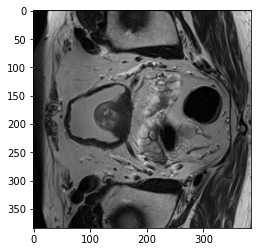

In [4]:
# Show image slice
imgSlice = img[:,:,20]
plt.imshow(imgSlice, cmap='gray')
plt.show()

In [5]:
# Load mask and see max min value of it
imagePathInput="/home/behnoud/Desktop/Desktop/data/volumes/mask"
imgPath = os.path.join(imagePathInput, 'Case02_segmentation_RUNMC.nii')
mask = nib.load(imgPath).get_fdata()
np.min(mask), np.max(mask), mask.shape, type(mask)

(0.0, 2.0, (384, 384, 24), numpy.memmap)

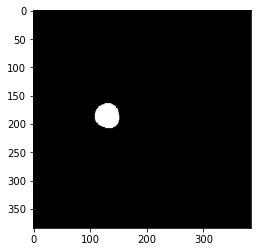

In [6]:
# Show mask slice
maskSlice = mask[:,:,20]
plt.imshow(maskSlice, cmap='gray')
plt.show()

In [7]:
# STEP 1 - Load and visualize data
# path of .nii format images and mask
dataInputPath = '/home/behnoud/Desktop/Desktop/data/volumes/'
imagePathInput = os.path.join(dataInputPath, 'img/')
maskPathInput = os.path.join(dataInputPath, 'mask/')

# path of .png format images and mask
dataOutputPath = '/home/behnoud/Desktop/Desktop/data/slices/'
imageSliceOutput = os.path.join(dataOutputPath, 'img/')
maskSliceOutput = os.path.join(dataOutputPath, 'mask/')

In [8]:
# Normalize image
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

def normalizeImageIntensityRange(img):
    img=scaler.fit_transform(img.reshape(-1, img.shape[-1])).reshape(img.shape)
    return img

nImg = normalizeImageIntensityRange(img)
np.min(nImg), np.max(nImg), nImg.shape, type(nImg)

(0.0, 1.0, (384, 384, 24), numpy.ndarray)

In [9]:
# Read image or mask volume
def readImageVolume(imgPath, normalize=False):
    img = nib.load(imgPath).get_fdata()
    if normalize:
        return normalizeImageIntensityRange(img)
    else:
        return img

In [10]:
# Save volume slice to file
def saveSlice(img, fname, path):
    img = np.uint8(img * 255)
    fout = os.path.join(path, f'{fname}.png')
    cv2.imwrite(fout, img)
    print(f'[+] Slice saved: {fout}', end='\r')

In [11]:
# Slice image in all directions and save the z axis (depth of Volume)
# STEP 2 - Slicing and saving
SLICE_Z = True
SLICE_DECIMATE_IDENTIFIER = 3

def sliceAndSaveVolumeImage(vol, fname, path):
    (dimx, dimy, dimz) = vol.shape

    print("dimz : "+str(dimz))

    cnt = 0
    if SLICE_Z:
        cnt += dimz
        print('Slicing Z: ')
        for i in range(dimz):
            saveSlice(vol[:,:,i], fname+f'-slice{str(i).zfill(SLICE_DECIMATE_IDENTIFIER)}_z', path)
    return cnt

In [12]:
# Read and process image volumes
for index, filename in enumerate(sorted(glob.iglob(imagePathInput+'*.nii'))):
    img = readImageVolume(filename, True)
    print(filename, img.shape, np.sum(img.shape), np.min(img), np.max(img))
    numOfSlices = sliceAndSaveVolumeImage(img, 'prostat'+str(index), imageSliceOutput)
    print(f'\n{filename}, {numOfSlices} slices created \n')

/home/behnoud/Desktop/Desktop/data/volumes/img/Case00_BMC.nii (384, 384, 32) 800 0.0 1.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/img/prostat0-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/img/Case00_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/img/Case00_RUNMC.nii (384, 384, 15) 783 0.0 1.0
dimz : 15
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/img/prostat1-slice014_z.png
/home/behnoud/Desktop/Desktop/data/volumes/img/Case00_RUNMC.nii, 15 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/img/Case01_BMC.nii (384, 384, 30) 798 0.0 1.0
dimz : 30
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/img/prostat2-slice029_z.png
/home/behnoud/Desktop/Desktop/data/volumes/img/Case01_BMC.nii, 30 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/img/Case01_RUNMC.nii (384, 384, 20) 788 0.0 1.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/D

/home/behnoud/Desktop/Desktop/data/volumes/img/Case15_BMC.nii (384, 384, 32) 800 0.0 1.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/img/prostat30-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/img/Case15_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/img/Case15_RUNMC.nii (384, 384, 20) 788 0.0 1.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/img/prostat31-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/img/Case15_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/img/Case16_BMC.nii (384, 384, 32) 800 0.0 1.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/img/prostat32-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/img/Case16_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/img/Case16_RUNMC.nii (384, 384, 20) 788 0.0 1.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Deskto

In [13]:
# Read and process image mask volumes
for index, filename in enumerate(sorted(glob.iglob(maskPathInput+'*.nii'))):
    img = readImageVolume(filename, False)
    print(filename, img.shape, np.sum(img.shape), np.min(img), np.max(img))
    numOfSlices = sliceAndSaveVolumeImage(img, 'segmented'+str(index), maskSliceOutput)
    print(f'\n{filename}, {numOfSlices} slices created \n')

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case00_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented0-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case00_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case00_segmentation_RUNMC.nii (384, 384, 15) 783 0.0 2.0
dimz : 15
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented1-slice014_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case00_segmentation_RUNMC.nii, 15 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case01_Segmentation_BMC.nii (384, 384, 30) 798 0.0 2.0
dimz : 30
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented2-slice029_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case01_Segmentation_BMC.nii, 30 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case01_segme

[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented9-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case04_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case05_Segmentation_BMC.nii (384, 384, 36) 804 0.0 2.0
dimz : 36
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented10-slice035_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case05_Segmentation_BMC.nii, 36 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case05_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented11-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case05_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case06_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slic

[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented18-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case09_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case09_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented19-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case09_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case10_Segmentation_BMC.nii (384, 384, 38) 806 0.0 2.0
dimz : 38
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented20-slice037_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case10_Segmentation_BMC.nii, 38 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case10_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/sli

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case14_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented28-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case14_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case14_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented29-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case14_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case15_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented30-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case15_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case15_se

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case19_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented38-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case19_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case19_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented39-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case19_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case20_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented40-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case20_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case20_se

[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented47-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case23_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case24_Segmentation_BMC.nii (384, 384, 35) 803 0.0 2.0
dimz : 35
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented48-slice034_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case24_Segmentation_BMC.nii, 35 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case24_segmentation_RUNMC.nii (384, 384, 19) 787 0.0 2.0
dimz : 19
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented49-slice018_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case24_segmentation_RUNMC.nii, 19 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case25_Segmentation_BMC.nii (384, 384, 34) 802 0.0 2.0
dimz : 34
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/sli

[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented56-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case28_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case28_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented57-slice019_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case28_segmentation_RUNMC.nii, 20 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case29_Segmentation_BMC.nii (384, 384, 32) 800 0.0 2.0
dimz : 32
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/slices/mask/segmented58-slice031_z.png
/home/behnoud/Desktop/Desktop/data/volumes/mask/Case29_Segmentation_BMC.nii, 32 slices created 

/home/behnoud/Desktop/Desktop/data/volumes/mask/Case29_segmentation_RUNMC.nii (384, 384, 20) 788 0.0 2.0
dimz : 20
Slicing Z: 
[+] Slice saved: /home/behnoud/Desktop/Desktop/data/sli